## Visualizing the Link Between Paracancerous and Cancer

### Data visualization, PCA and UMAP using the cancer dataset.

We first load data into a Pandas DataFrame. It dives into the realm of dimensionality reduction by performing PCA and UMAP on the dataset. 

In [ ]:
# These are the package import statements. As you can see, you'll be using pandas to manipulate raw data and matplotlib and seaborn for data visualization.
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
SRS_Data = pd.read_excel('Comparison_Intensity_ratio_human-CRC.xlsx')
print(SRS_Data.head(10)) 


           Types  Intensity_X  Intensity_Y     Ratio
0  Paracancerous     0.067799     0.096872  0.588277
1  Paracancerous     0.028009     0.136702  0.829952
2  Paracancerous     0.158747     0.177080  0.527295
3  Paracancerous     0.073983     0.147623  0.666152
4  Paracancerous     0.256923     0.192926  0.428869
5  Paracancerous     0.307422     0.374583  0.549237
6  Paracancerous     0.308993     0.165719  0.349094
7  Paracancerous     0.510920     0.337297  0.397654
8  Paracancerous     0.421760     0.332222  0.440623
9  Paracancerous     0.476976     0.473149  0.497986


# PCA with Data

In [2]:
# Import additional packages for doing PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Variance explained by the first two principal components: 0.97


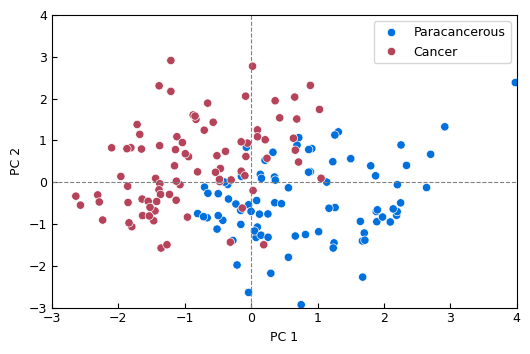

: 

In [ ]:
# Features
X = SRS_Data[['Intensity_X', 'Intensity_Y', 'Ratio']]
 
# Target variable
y = SRS_Data['Types']
 
# Standardize the features
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
 
# Perform PCA
pca2 = PCA(n_components=2)
pca2.fit(X_scaled)
principalComponents = pca2.fit_transform(X_scaled)
 
# Calculate variance explained by the first two principal components
variance_explained_by_first_two_components = np.sum(pca2.explained_variance_ratio_[:2])
print(f"Variance explained by the first two principal components: {variance_explained_by_first_two_components:.2f}")
 
# Define new dataframe with principal components
df_pca = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2'])
df_pca = pd.concat([df_pca, SRS_Data[['Types']]], axis=1)
 
# Plotting
plt.figure(figsize=(6, 3.8))
axes = plt.gca()  # Get the current axis to pass to seaborn
sns.scatterplot(
    data=df_pca, 
    x='principal component 1', 
    y='principal component 2', 
    hue='Types', 
    palette={'Cancer': (181/255,67/255,90/255), 'Paracancerous': (0/255,112/255,222/255)}, 
    ax=axes,
    # legend=False  
)

# Set axis limits
plt.xlim(-3, 4)  # Adjust these limits as needed
plt.ylim(-3, 4)  # Adjust these limits as needed
 
# Add lines for x=0 and y=0
plt.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
 
# plt.title('PC1 vs PC2 by Types')
plt.xlabel('PC 1', fontsize=9)
plt.ylabel('PC 2', fontsize=9)

# Modified tick parameters with inward direction
plt.tick_params(axis='both', which='major', labelsize=9, direction='in')
 
# Set legend with font size
plt.legend(loc='upper right', fontsize=9)
plt.savefig("PCA.svg", dpi=300,format="svg")
plt.show()

# UMAP

In [ ]:
from umap import UMAP

# reducer = UMAP(a=None, angular_rp_forest=False, b=None,
#      force_approximation_algorithm=False, init='spectral', learning_rate=1.0,
#      local_connectivity=1.0, low_memory=False, metric='euclidean',
#      metric_kwds=None, min_dist=0.09, n_components=2, n_epochs=None,
#      n_neighbors=8, negative_sample_rate=5, output_metric='euclidean',
#      output_metric_kwds=None, random_state=42, repulsion_strength=1.0,
#      set_op_mix_ratio=1.0, spread=1.0, target_metric='categorical',
#      target_metric_kwds=None, target_n_neighbors=-1, target_weight=0.5,
#      transform_queue_size=4.0, transform_seed=42, unique=False, verbose=False)

# 标准化特征
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# umap_embedding = reducer.fit_transform(X_scaled)


# 使用UMAP进行降维
umap_reducer = UMAP(n_components=2)
umap_embedding = umap_reducer.fit_transform(X_scaled)


# 将UMAP结果转换为DataFrame
df_umap = pd.DataFrame(data=umap_embedding, columns=['UMAP 1', 'UMAP 2'])
df_umap = pd.concat([df_umap, SRS_Data[['Types']]], axis=1)

# 绘图
plt.figure(figsize=(8, 6))
axes = plt.gca()  # 获取当前轴以传递给seaborn
sns.scatterplot(
    data=df_umap, 
    x='UMAP 1', 
    y='UMAP 2', 
    hue='Types', 
    palette={'Cancer': (181/255,67/255,90/255), 'Paracancerous': (0/255,112/255,222/255)}, 
    ax=axes
)

# 设置坐标轴范围（根据需要调整）
# plt.xlim(-2, 15)
# plt.ylim(-2, 15)

# 添加网格线
plt.grid(True)

# plt.title('UMAP 1 vs UMAP 2 by Types')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
# Set legend with font size
plt.legend( loc='upper right', fontsize=14)
plt.show()